In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import statsmodels.api as sm
from lidglm import ExtendedGLM_Utils, TransformerUtils
from tqdm import tqdm
from scipy.special import expit #sigmoid function

plt.rcParams['text.usetex'] = True

C:\Users\splittgerber\AppData\Local\anaconda3\envs\lidglm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-25 17:07:30,818	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-07-25 17:07:31,094	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# we set the random seed for reproducibility
np.random.seed(123)
torch.manual_seed(123)

#generate synthetic data:
num_samples = 100
def two_d_function(x_1, x_2):
    return expit(x_1 + np.sin(x_1) - x_2)


x_1_points, x_2_points = np.meshgrid(np.linspace(0, 2*np.pi, num_samples), np.linspace(0, 2*np.pi, num_samples))

exog = np.array([x_1_points.flatten(), x_2_points.flatten()]).T
endog = np.random.binomial(1, two_d_function(x_1_points, x_2_points).flatten())

plot_dict = {
    "True Data": two_d_function(x_1_points, x_2_points)
}


In [3]:
#Train a GLM:

sm_glm= sm.GLM(endog, sm.add_constant(exog, prepend=True), family=sm.families.Binomial(sm.families.links.Logit()))
sm_results = sm_glm.fit()
plot_dict["GLM"] = sm_results.predict(sm.add_constant(np.column_stack((x_1_points.flatten(), x_2_points.flatten())), prepend = True)).reshape(x_1_points.shape)


100%|██████████| 400/400 [00:33<00:00, 11.86it/s]


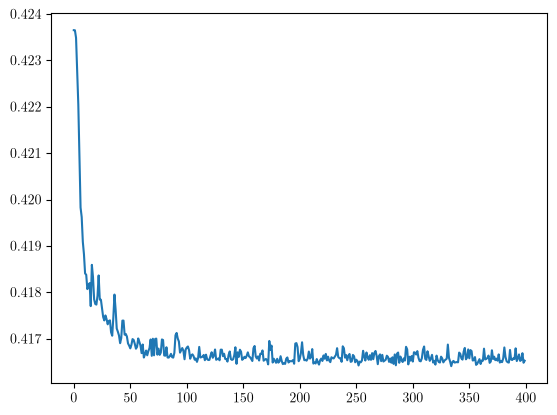

In [4]:
# Train a LiD-GLM with a small Lipschitz bound:
util = ExtendedGLM_Utils()
util2 = TransformerUtils()
lidglm_activation = "group_sort"
small_lipschitz = 1.25
epochs = 400
nu_1 = util2.initialize_transformer(num_params=2, lipschitz_const=small_lipschitz, width =8, depth = 2, domain_codomain=2, activation_string=lidglm_activation, group_size =2)

extended_glm, endog_tensor, exog_tensor = util.convert_sm_glm(sm_results, nu_1, bias = "First")
extended_glm.used_device = "cpu"
loss_hist = util.train_model(extended_glm, exog=exog_tensor, endog=endog_tensor, epochs=epochs, lr=0.01, loss_crit = "log_like", early_stopping=True, part_to_train="network")[0]
plt.plot(loss_hist)
plot_dict[f"LiD-GLM, $L(\\nu_p) \\leq$ {small_lipschitz-1}"] = extended_glm.predict(exog_tensor.to(extended_glm.used_device)).detach().cpu().numpy().reshape(x_1_points.shape)


100%|██████████| 400/400 [00:33<00:00, 11.89it/s]


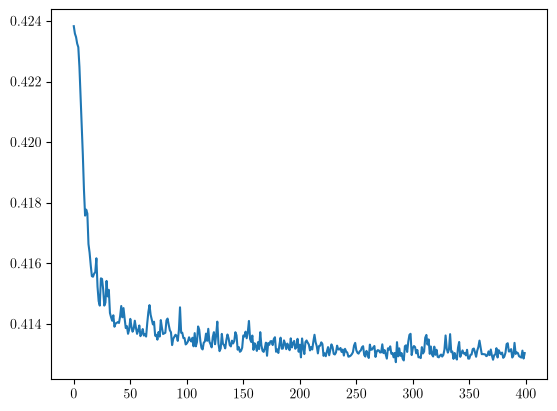

In [5]:
# Train a LiD-GLM with a larger Lipschitz bound:
util = ExtendedGLM_Utils()
util2 = TransformerUtils()

large_lipschitz = 1.7
epochs = 400
nu_1 = util2.initialize_transformer(num_params=2, lipschitz_const=large_lipschitz, width =8, depth = 2, domain_codomain=2, activation_string=lidglm_activation, group_size =2)

extended_glm, endog_tensor, exog_tensor = util.convert_sm_glm(sm_results, nu_1, bias = "First")
extended_glm.used_device = "cpu"
loss_hist = util.train_model(extended_glm, exog=exog_tensor, endog=endog_tensor, epochs=epochs, lr=0.01, loss_crit = "log_like", early_stopping=True, part_to_train="network")[0]
plt.plot(loss_hist)
plot_dict[f"LiD-GLM, $L(\\nu_p) \\leq$ {large_lipschitz-1}"] = extended_glm.predict(exog_tensor.to(extended_glm.used_device)).detach().cpu().numpy().reshape(x_1_points.shape)

  1%|          | 3/400 [00:00<00:15, 25.14it/s]

Epoch 0, Loss: 0.5027970671653748


 26%|██▋       | 105/400 [00:04<00:10, 27.66it/s]

Epoch 100, Loss: 0.7063406705856323


 51%|█████     | 204/400 [00:07<00:07, 26.78it/s]

Epoch 200, Loss: 0.4201933741569519


 76%|███████▌  | 304/400 [00:11<00:03, 26.92it/s]

Epoch 300, Loss: 0.2121024876832962


100%|██████████| 400/400 [00:15<00:00, 26.28it/s]


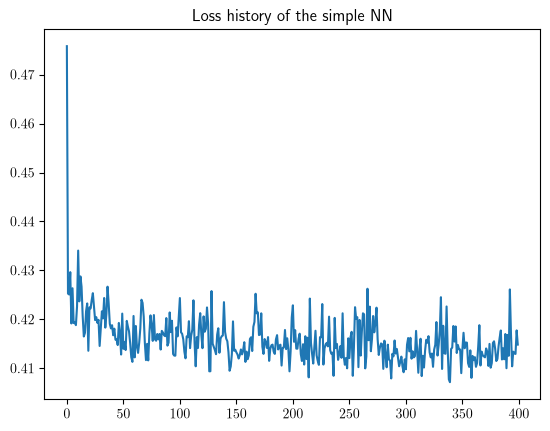

In [6]:
#try a simple NN on the data:


#we train a simple neural network on the data with pytorch:
class SimpleNN(nn.Module):
    def __init__(self, width, depth):
        self.input_dim = 2
        self.output_dim = 1
        super(SimpleNN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(depth):
            if i == 0:
                self.layers.append(nn.Linear(self.input_dim, width))
                self.layers.append(nn.ReLU())
            elif i < depth - 1:
                self.layers.append(nn.Linear(width, width))
                self.layers.append(nn.ReLU())
            else:
                self.layers.append(nn.Linear(width, self.output_dim))
                self.layers.append(nn.Sigmoid())

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
#initialize the model:
model = SimpleNN(width=20, depth=3)
model = model.to("cpu")
model.train()
#initialize the loss function and optimizer:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
#train the model:
epochs = 400
batch_size = 256
loss_hist = []
data_loader = torch.utils.data.DataLoader(list(zip(exog_tensor, endog_tensor)), batch_size=batch_size, shuffle=True)
for epoch in tqdm(range(epochs)):
    batchwise_loss = np.array([])
    for batch_X, batch_y in data_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X).reshape(-1)
        loss = loss_fn(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        batchwise_loss = np.append(batchwise_loss, loss.item())
    loss_hist.append(batchwise_loss.mean())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

plt.plot(loss_hist)
plt.title("Loss history of the simple NN")
plot_dict["Unconstrained NN"] = model(torch.tensor(exog_tensor.to("cpu").numpy(), dtype=torch.float32)).detach().numpy().reshape(x_1_points.shape)

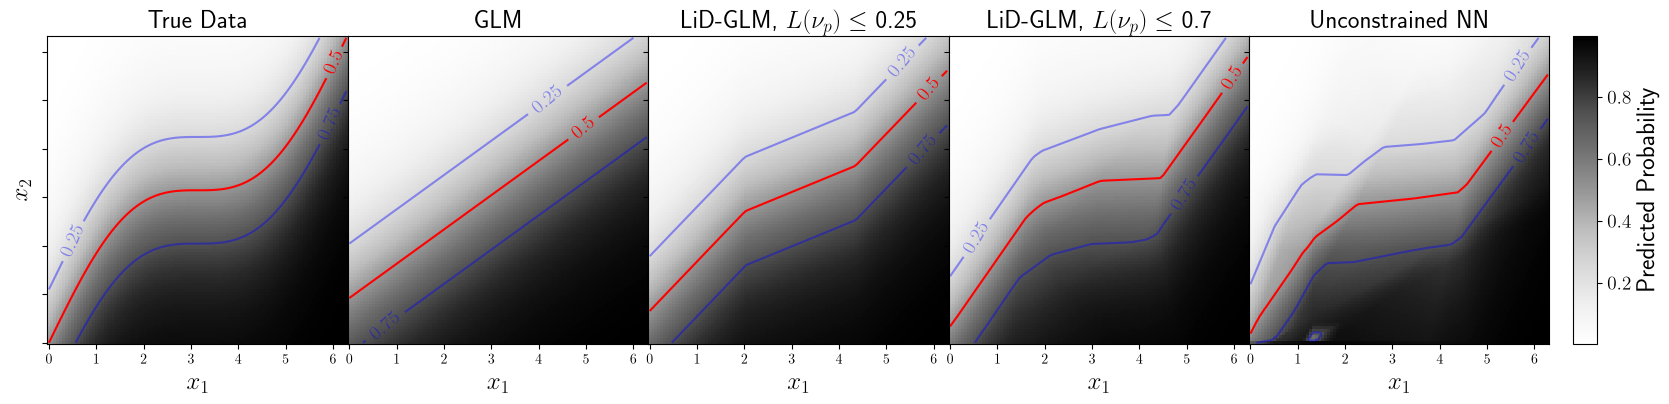

In [7]:
# we now plot the results:

fig, axs = plt.subplots(1, 7, figsize=(20, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 0.08, 0.08]})
#the colorbar will be the same for all plots is only given a fraction of the horizontal plot space:

for i in range(5):
    if i > 0:
        # set y sharing:
        axs[i].sharey(axs[0])
        axs[i].set_yticklabels([])
    else:
        axs[i].set_ylabel("$x_2$", fontsize=18)
    model_name = list(plot_dict.keys())[i]
    model_output = plot_dict[model_name]
    colmesh = axs[i].pcolormesh(x_1_points, x_2_points, model_output, cmap='Greys')
    axs[i].set_xlabel("$x_1$", fontsize=18)
    
    axs[i].set_title(model_name, fontsize=18)
    #add contour lines:
    one_dimensional_x = np.linspace(0, 2*np.pi, num_samples)
    contours = axs[i].contour(x_1_points, x_2_points, model_output, levels=[0.25,0.75], colors='blue', alpha =.4)
    axs[i].clabel(contours, inline=True, fontsize=14)

    mean = axs[i].contour(x_1_points, x_2_points, model_output, levels=[0.5], colors='red')
    axs[i].clabel(mean, inline=True, fontsize=14)
fig.colorbar(colmesh, cax = axs[-1], label='Predicted Probability')
axs[-1].tick_params(labelsize=14)
axs[-1].set_ylabel("Predicted Probability", fontsize=18)
plt.subplots_adjust(wspace=0, hspace=0) # for "=0", no space is left between plots

axs[-2].remove() # remove the second to last axis, which was only there for spacing reasons

fig.savefig("T_p_visualisation.pdf", bbox_inches='tight')